# ex.py

### Class Definition

In [1]:
import pyvisa
import time

class RigolInstrument:
    def __init__(self, resource_name, verbose=1):
        self.verbose = verbose
        self.inst = pyvisa.ResourceManager("@py").open_resource(resource_name)
        self.inst.timeout = 5000
        self.inst.encoding = 'utf-8'
        self.idn = self.get_idn()
        self.instrument_type = self.classify_instrument()

    def get_idn(self):
        try:
            self.inst.write('*IDN?')
            time.sleep(0.1)
            return self.inst.read().strip()
        except pyvisa.errors.VisaIOError:
            if self.verbose >= 2:
                print(f"  ✗ IDN query failed:")
            return "Unknown"

    def getter_idn(self):
        return self.idn

    def classify_instrument(self):
        idn_upper = self.idn.upper()
        if "RIGOL" in idn_upper and "DG" in idn_upper:
            return "generator"
        elif "RIGOL" in idn_upper and ("DS" in idn_upper or "MSO" in idn_upper):
            return "oscilloscope"
        else:
            return "unknown"

    def write(self, command):
        self.inst.write(command)

    def query(self, command):
        return self.inst.query(command)
        
    def read(self):
        return self.inst.read()

    def close(self):
        self.inst.close()
        time.sleep(2)
    
    def __str__(self):
        return f"{self.instrument_type.capitalize()} - IDN: {self.idn}"

    def toggle(channel, state, self):
        # ------ CH1 ----------
        if channel == "CH1":
            if state == "ON":
                self.write("OUTP1 ON")
            else:
                self.write("OUTP1 OFF")
        # ------ CH2 ----------
        elif channel == "CH2":
            if state == "ON":
                self.write('OUTP:CH2 ON ')
            else:
                self.write('OUTP:CH2 OFF ')
        return

    def generate_waveform(self, channel, waveform_type, frequency, amplitude, offset=0, phase=0, duty_cycle=50):
        """Note that writing to CH1 is different from writing to CH2...."""
        args = f"{frequency}, {amplitude}, {offset} "
        
        if channel == "CH1":
            # print(channel)
            self.write('VOLT:UNIT VPP')
            time.sleep(0.05)
            self.write(f'APPL:{waveform_type} {args}')   # e.g. APPL:RAMP 1000, 2.5, 0.5
            time.sleep(0.05)
            self.write(f'PHAS {phase} ')
            time.sleep(0.05)
            self.write("OUTP1 ON")
            # self.toggle("CH1", "ON", self)

        else:
            # for CH2 use the CH-specific notation...
            self.write(f'VOLT:UNIT:{channel} VPP')
            time.sleep(0.05)
            self.write(f'APPL:{waveform_type}:{channel} {args}')  # e.g. APPL:SQUare:CH2 1000, 2.5, 0.5
            time.sleep(0.05)
            self.write(f'PHAS:{channel} {phase} ')
            time.sleep(0.05)
            self.write('OUTP:CH2 ON ')
            # self.toggle(f"CH2", "ON", self)

    def generate_duty_cycle(self, channel, waveform_type, frequency, amplitude, offset=0, phase=0, duty_cycle=50):
        """ONLY for SQUare and PULSe."""

        if waveform_type not in ["SQUare", "PULSe"] : 
            print("Error: Duty cycle is only for SQUare and PULSe functions.")
            return

        if channel == "CH1":
            self.write("*RST")
            time.sleep(1)
            if waveform_type == "PULSe":
                print("Error: PULSe not yet implemented.")
                return
                # self.write(f"APPL:PULSe {frequency},{amplitude},{offset}")  # Syntax :  APPL:PULSe <Freq>,<Amp>,<Offset>
                # time.sleep(1)
                # self.write(f"PULSe:DCYC {duty_cycle}")                      # Syntax : PULSe:DCYCle <percent>


            else :
                self.write(f"APPL:SQU {frequency},{amplitude},{offset}")  # Syntax : APPL:SQU <Freq>,<Amp>,<Offset>
                time.sleep(1)
                self.write(f"FUNC:SQU:DCYC {duty_cycle}")                 # Syntax : FUNC:SQU:DCYC <percent>

            time.sleep(1)
            self.write("OUTP1 ON")
            time.sleep(1)

        else:
            print("Error: Channels other than CH1 not supported by the current class definition.")




# =========================================


# Detect Connected instruments
def detect_rigol_instruments(verbose=1):
    """
    Retourne un tuple (generator, oscilloscope) si présents, sinon None.
    
    Verbose : 0 = silent, 1 = normal, 2 = debug
    
    """
    rm = pyvisa.ResourceManager("@py")
    devices = [d for d in rm.list_resources() if "USB" in d]

    # prints
    if verbose >=2:
        print(f"Devices : {devices}")

    generator = None
    oscilloscope = None
    if verbose >=1: print("Detecting...")

    for dev in devices:
        rigol = RigolInstrument(dev)
        if rigol.instrument_type == "generator":
            generator = rigol
            if verbose >=2: print(f"Detected Generator: {generator}")
            if verbose == 1: print(f"Generator Detected.")

        elif rigol.instrument_type == "oscilloscope":
            oscilloscope = rigol
            if verbose >=2: print(f"Detected Oscilloscope: {oscilloscope}")
            if verbose == 1: print(f"Oscilloscope Detected.")
    return generator, oscilloscope



### Connection Test

In [2]:
generator, oscilloscope = detect_rigol_instruments(verbose=1)

# Close connection
if generator    : generator.close()
if oscilloscope : oscilloscope.close()

Detecting...
Oscilloscope Detected.
Generator Detected.


### Waveform Generator - DG1022

In [3]:
# Close connection
if generator    : generator.close()
if oscilloscope : oscilloscope.close()

In [4]:
# Available Functions
wave = {
    "sin":"SINusoid",
    "square" : "SQUare",
    "ramp" : "RAMP",
    "pulse" : "PULSe",
    "noise" : "NOISe",
    "dc" : "DC"
}

In [ ]:
# Example of usage
generator, oscilloscope = detect_rigol_instruments(verbose=1)
# Example - Generate all signals
# for w in wave:
#     generator.generate_waveform(channel="CH1", waveform_type=w, frequency=1000, amplitude=5)
#     print(f'CH1 is a : {w}')
#     time.sleep(2)



# generator.generate_waveform(channel="CH1", waveform_type="sin", frequency=1000, amplitude=5)





# Close connection
if generator    : generator.close()
if oscilloscope : oscilloscope.close()


Detecting...
Generator Detected.
Oscilloscope Detected.
CH1 is a : sin
CH1 is a : square
CH1 is a : ramp
CH1 is a : pulse
CH1 is a : noise
CH1 is a : dc


In [5]:
# Duty Cycle 

# FUNC:SQU:DCYC 50
# PULS:DCYC 50
# fg.write("FUNC:SQU:DCYC 90")


generator, oscilloscope = detect_rigol_instruments(verbose=1)

generator.generate_duty_cycle(
    channel="CH1",
    waveform_type=wave["square"],
    frequency=2000,
    amplitude=10,
    offset=0,
    phase=0,
    duty_cycle=10
)

# Close connection
if generator    : generator.close()
if oscilloscope : oscilloscope.close()


Detecting...
Oscilloscope Detected.
Generator Detected.


### Oscilloscope - DS1104ZPLUS

In [6]:
# ------ Measure any waveform parameter of a channel -------
import time

# Available parameters :
    # {VMAX|VMIN|VPP|VTOP|VBASe|VAMP|VAVG|
    # VRMS|OVERshoot|PREShoot|MARea|MPARea|
    # PERiod|FREQuency|RTIMe|FTIMe|PWIDth|
    # NWIDth|PDUTy|NDUTy|RDELay|FDELay|
    # RPHase|FPHase|TVMAX|TVMIN|PSLEWrate|
    # NSLEWrate|VUPper|VMID|VLOWer|VARIance|
    # PVRMS|PPULses|NPULses|PEDGes|NEDGes}


def get_waveform_param(osc, params='VRMS', channel=1):

    # Query chanel
    osc.write(f':MEAS:SOUR CHANnel{channel}')
    time.sleep(0.05)

    # Query param
    result = osc.query(f':MEAS:ITEM? {params[i]}')

    return result


# mutliple params
# def get_waveform_param(osc, params={'VRMS'}, channel=1):
#     osc.write(f':MEAS:SOUR CHANnel{channel}')
#     time.sleep(0.05)

#     dict = {}
#     for i in len(params):
#         result = osc.query(f':MEAS:ITEM? {params[i]}')
#         time.sleep(0.05)
#         dict[f"{params[i]}"] = float(result.strip())
        
#     return dict

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Function Definitions :
#   1. capture_waveform     : given the channel (int), request the waveform data and saves it into a clean dict.
#   2. plot_single_waveform : given the dict of the previous function, plot it using matplotlib.
#   3. saveToCSV            : given the dict of the previous funtction, save it for later potting.


def capture_waveform(osc, channel=1, verbose=True):
    """Capture waveform using proper IEEE block format (WORKING VERSION)"""
    
    # Configure oscilloscope
    # osc.write(f':WAV:SOUR {channel}')
    osc.write(f":WAVeform:SOURce CHANnel{channel}")
    time.sleep(0.2)
    osc.write(':WAV:MODE NORM')
    time.sleep(0.2)
    osc.write(':WAV:FORM BYTE')
    time.sleep(0.2)
    
    # Get preamble (metadata about the waveform)
    preamble = osc.query(':WAV:PRE?')
    preamble_values = preamble.split(',')
    
    points      = int(preamble_values[2])           # How many samples
    x_increment = float(preamble_values[4])    # Time between samples
    x_origin    = float(preamble_values[5])       # Starting time
    y_increment = float(preamble_values[7])    # Voltage per unit
    y_origin    = float(preamble_values[8])       # Zero voltage
    y_reference = int(preamble_values[9])      # Center byte value (usually 127)
    
    if verbose:
        print(f"  Capturing {points} samples from {channel}...")
    
    # CRITICAL: Write the query command FIRST
    osc.write(':WAV:DATA?')
    time.sleep(0.5)  # Let scope prepare data
    
    # Set timeout for binary data
    original_timeout = osc.inst.timeout
    osc.inst.timeout = 30000  # 30 second timeout
    
    try:
        # Read the IEEE block header first
        # Format: #9000001200 (11 bytes) where 9=num_digits, 000001200=data_length
        header = osc.inst.read_raw(11)
        
        if header[0:1] != b'#':
            raise ValueError(f"Expected IEEE header starting with '#', got {header}")
        
        # Parse header to get actual data length
        num_digits = int(header[1:2])
        data_length_str = header[2:2+num_digits].decode('utf-8')
        data_length = int(data_length_str)
        
        if verbose: print(f"  Header: {header}, data_length={data_length}")
        
        # Now read the actual sample bytes
        raw_bytes = osc.inst.read_raw(data_length)
        
        # FIXED: Convert bytes to numpy array and use actual mean as reference
        # This removes the DC offset issue from y_reference/y_origin mismatch
        byte_array = np.frombuffer(raw_bytes, dtype=np.uint8)
        y_data = (byte_array - np.mean(byte_array)) * y_increment
        
        # Create time axis
        time_axis = np.arange(len(y_data)) * x_increment + x_origin
        
        preamble_dict = {
            'points': points,
            'x_increment': x_increment,
            'x_origin': x_origin,
            'y_increment': y_increment,
            'y_origin': y_origin,
            'y_reference': y_reference
        }
        
        if verbose: print(f"  ✓ Captured {len(y_data)} points successfully")
        return time_axis, y_data, preamble_dict
        
    finally:
        osc.inst.timeout = original_timeout

def plot_single_waveform(time_ms, voltage_array, frequency, amplitude, vpp_measured, vmax, vmin, vrms):
    """Plot single waveform with all parameters in legend."""
    # CREATE figure and axis (was undefined before)
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.plot(time_ms, voltage_array, linewidth=1.5, color='blue')
    ax.axhline(vmax, color='red', linestyle='--', linewidth=1, alpha=0.7, label=f'Vmax: {vmax:.3f} V')
    ax.axhline(vmin, color='green', linestyle='--', linewidth=1, alpha=0.7, label=f'Vmin: {vmin:.3f} V')
    ax.axhline(0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
    
    ax.set_xlabel('Time (ms)', fontsize=12)
    ax.set_ylabel('Voltage (V)', fontsize=12)
    ax.set_title(f'Sine Wave Measurement\nFrequency: {frequency/1000:.1f} kHz | VPP: {vpp_measured:.3f} V', 
                    fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Create legend with all key parameters
    legend_text = f"Frequency: {frequency/1000:.1f} kHz\nVPP (set): {amplitude:.3f} V\nVPP (meas): {vpp_measured:.3f} V\nVmax: {vmax:.3f} V\nVmin: {vmin:.3f} V\nVRMS: {vrms:.3f} V"
    ax.text(0.98, 0.97, legend_text,
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment='top',
            horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

def saveToCSV(output_file, time_array, voltage_array, frequency, amplitude, vpp_measured, vmax, vmin, vrms):
    """Save waveform data to CSV file with metadata header."""
    import csv
    from datetime import datetime
    
    # Generate timestamp
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    
    # Open file ONCE and write everything before closing
    with open(output_file, 'w', newline='') as f:
        writer = csv.writer(f)
        
        # Write metadata header
        writer.writerow(['# Automated Sine Wave Measurement'])
        writer.writerow(['# Timestamp', timestamp])
        writer.writerow(['# Frequency (Hz)', frequency])
        writer.writerow(['# Amplitude Set (Vpp)', amplitude])
        writer.writerow(['# VPP Measured (V)', f"{vpp_measured:.6f}"])
        writer.writerow(['# Vmax (V)', f"{vmax:.6f}"])
        writer.writerow(['# Vmin (V)', f"{vmin:.6f}"])
        writer.writerow(['# VRMS (V)', f"{vrms:.6f}"])
        writer.writerow([])  # Blank line separator
        writer.writerow(['Time (s)', 'Voltage (V)'])
        
        # Write all data rows (INSIDE the with block)
        for t, v in zip(time_array, voltage_array):
            writer.writerow([f"{t:.9f}", f"{v:.6f}"])
    
    print(f"✓ Data saved to {output_file}")


#### Capture and Plot (1 Waveform)

Detecting...
Oscilloscope Detected.
Generator Detected.
  Capturing 1200 samples from 1...
  Header: b'#9000001200', data_length=1200
  ✓ Captured 1200 points successfully


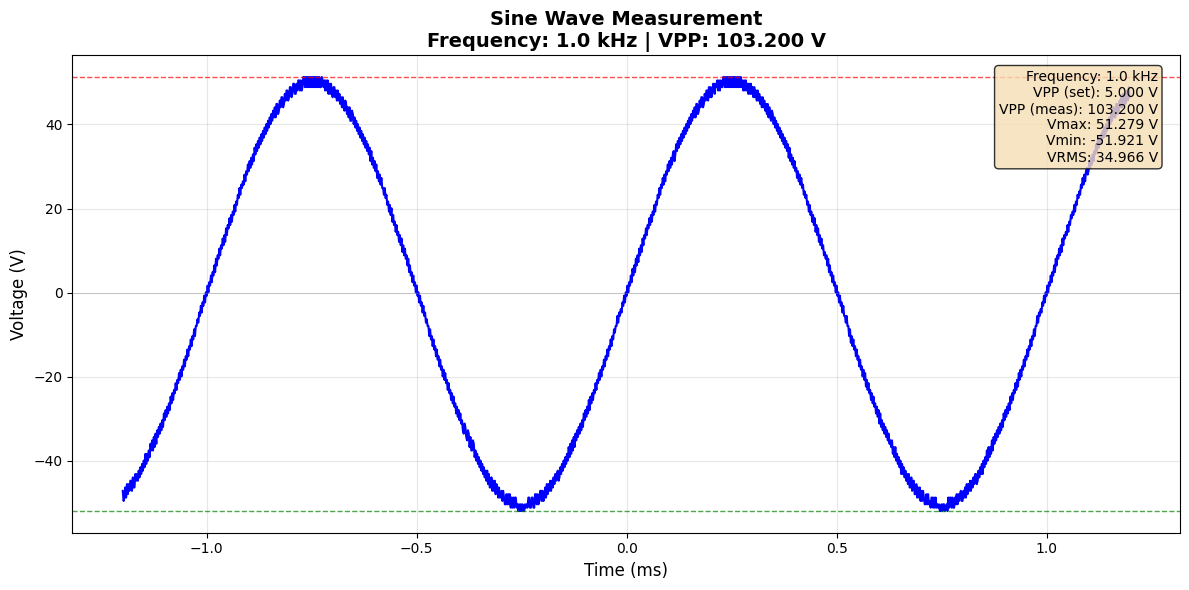

In [8]:
# Example - Generate a sine signal and plot it using matplotlib.
generator, oscilloscope = detect_rigol_instruments(verbose=1)

frequency = 1000
amplitude = 5


# 1. Generate Waveform
generator.generate_waveform(
    channel="CH1",
    waveform_type=wave["sin"],
    frequency=frequency,
    amplitude=amplitude,
    phase=0
)


# 2. Capture on Oscilloscope 
time_array, voltage_array, preamble = capture_waveform(oscilloscope, 1)

# 3. Params
vpp_measured = np.max(voltage_array) - np.min(voltage_array)
vmax = np.max(voltage_array)
vmin = np.min(voltage_array)
vrms = np.sqrt(np.mean(voltage_array**2))
time_ms = time_array * 1e3  # Convert time to ms for readability

# 4. Plot waveform
plot_single_waveform(time_ms, voltage_array, frequency, amplitude, vpp_measured, vmax, vmin, vrms)


# Close connection
if generator    : generator.close()
if oscilloscope : oscilloscope.close()

#### Capture and Plot (2 Waveforms)

Detecting...
Oscilloscope Detected.
Generator Detected.
  Capturing 1200 samples from 1...
  Header: b'#9000001200', data_length=1200
  ✓ Captured 1200 points successfully
  Capturing 1200 samples from 2...
  Header: b'#9000001200', data_length=1200
  ✓ Captured 1200 points successfully


/tmp/ipykernel_507055/3653120008.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', fontsize=9)


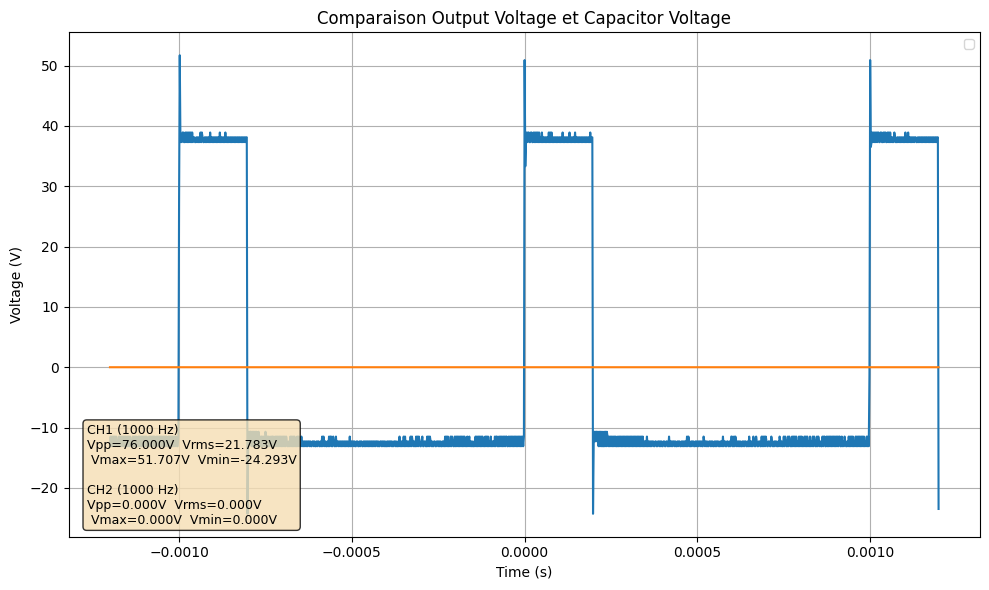

In [10]:
# Example - Generate and plot 2 channels.

generator, oscilloscope = detect_rigol_instruments(verbose=1)


frequency = 1000
amplitude = 5


# 1. Generate Waveform
generator.generate_duty_cycle(
    channel="CH1",
    waveform_type=wave["square"],
    frequency=frequency,
    amplitude=amplitude,
    offset=0,
    phase=0,
    duty_cycle=10
)
generator.generate_waveform(
    channel="CH2",
    waveform_type=wave["sin"],
    frequency=frequency,
    amplitude=amplitude,
    phase=0
)


# 2. Capture on Oscilloscope 
time_array_1, voltage_array_1, preamble_1 = capture_waveform(oscilloscope, 1)
time_array_2, voltage_array_2, preamble_2 = capture_waveform(oscilloscope, 2)


# 3. Params CH1
vpp_measured_1 = np.max(voltage_array_1) - np.min(voltage_array_1)   # TODO : query oscilloscope for these directly
vmax_1 = np.max(voltage_array_1)
vmin_1 = np.min(voltage_array_1)
vrms_1 = np.sqrt(np.mean(voltage_array_1**2))

# 4. Params CH2
vpp_measured_2 = np.max(voltage_array_2) - np.min(voltage_array_2)
vmax_2 = np.max(voltage_array_2)
vmin_2 = np.min(voltage_array_2)
vrms_2 = np.sqrt(np.mean(voltage_array_2**2))


# (Optionnal) - Print characteristics
# print("======== CH1 Characteristics (Square, 10% duty cycle) =========")
# print(f"Vpp:  {vpp_measured_1:.4f} V")
# print(f"Vmax: {vmax_1:.4f} V")
# print(f"Vmin: {vmin_1:.4f} V")
# print(f"Vrms: {vrms_1:.4f} V")

# print("\n======== CH2 Characteristics (Sine) =========")
# print(f"Vpp:  {vpp_measured_2:.4f} V")
# print(f"Vmax: {vmax_2:.4f} V")
# print(f"Vmin: {vmin_2:.4f} V")
# print(f"Vrms: {vrms_2:.4f} V")



# 5. Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(time_array_1, voltage_array_1)
ax.plot(time_array_2, voltage_array_2)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Voltage (V)")
ax.grid(True, which="both")
ax.legend(loc='upper right', fontsize=9)
ax.set_title("Comparaison Output Voltage et Capacitor Voltage")

stats_text = (
    f"CH1 ({frequency} Hz)\n"
    f"Vpp={vpp_measured_1:.3f}V  Vrms={vrms_1:.3f}V \n Vmax={vmax_1:.3f}V  Vmin={vmin_1:.3f}V\n\n"
    f"CH2 ({frequency} Hz)\n"
    f"Vpp={vpp_measured_2:.3f}V  Vrms={vrms_2:.3f}V \n Vmax={vmax_2:.3f}V  Vmin={vmin_2:.3f}V"
)
ax.text(
    0.02, 0.02, stats_text,
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment='bottom',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
)

plt.tight_layout()
plt.show()



# Close connection
if generator    : generator.close()
if oscilloscope : oscilloscope.close()

In [ ]:
generator, oscilloscope = detect_rigol_instruments(verbose=1)

oscilloscope.query(':AUToscale')


# Close connection
if generator    : generator.close()
if oscilloscope : oscilloscope.close()


---

end